# ResNet101 — Cross-Crop Knowledge Distillation from Lentil Teacher (Phase 3)

**Objective:** Train a ResNet101 student on the Beans dataset using feature-based knowledge distillation from a ResNet101 teacher model that was trained on the Lentil dataset.

**Teacher:** ResNet101 (trained on Lentil disease classification, 4 classes — frozen during distillation)
**Student:** ResNet101 (trained on Beans disease classification, 3 classes)

**KD Method:** Feature-based (hint-based) distillation
- Teacher hint layers: `conv4_block23_out` (14x14x1024) and `conv5_block3_out` (7x7x2048)
- Student features are projected via 1x1 Conv2D to match teacher channel dimensions
- Loss: `total_loss = classification_loss + 0.2 * normalized_feature_MSE`

**Scientific Rationale:** Both lentils and beans belong to the Fabaceae family, sharing similar leaf morphology and disease manifestations (e.g., rust). This taxonomical similarity enables meaningful cross-crop knowledge transfer.

**Context:** This is Phase 3 of the project. Results are compared against the baseline (Phase 2, without KD) to quantify the benefit of cross-crop knowledge distillation.

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

## Step 1: Load and Freeze the Teacher Model

Loading the ResNet101 teacher model trained on the Lentil Augmented Dataset. All teacher parameters are frozen — the teacher serves only as a feature extractor during distillation.

In [2]:
teacher = tf.keras.models.load_model(
    r"C:\Users\k nithin\Downloads\M.Tech Project\Code\ResNet101_lentil_10.keras",
    compile=False
)

teacher.trainable = False  # 🔒 Freeze teacher completely
print("Teacher loaded and frozen")


Teacher loaded and frozen


In [3]:
print("Trainable variables in teacher:",
      len(teacher.trainable_variables))

Trainable variables in teacher: 0


## Step 2: Define Teacher Hint Layers

Selecting intermediate layers from the teacher whose feature representations will be transferred to the student. These layers capture progressively abstract visual features relevant to disease patterns.

In [4]:
TEACHER_HINT_LAYERS = [
    "conv4_block23_out",  # deep semantic features
    "conv5_block3_out"    # highest-level features
]

In [5]:
teacher_feature_extractor = Model(
    inputs=teacher.input,
    outputs=[teacher.get_layer(name).output for name in TEACHER_HINT_LAYERS],
    name="teacher_feature_extractor"
)

teacher_feature_extractor.trainable = False

In [6]:
teacher_feature_extractor.summary()

Model: "teacher_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 42,658,176 (162.73 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 42,658,176 (162.73 MB)

## Step 3: Build and Configure the Student Model

Building the ResNet101 student model with ImageNet-pretrained weights. Since the student shares the same architecture as the teacher, the student hint layers (`conv4_block23_out`, `conv5_block3_out`) correspond directly to the teacher hint layers with matching spatial resolutions and channel dimensions.

In [7]:
student_base = ResNet101(
    weights="imagenet",   # important: general visual priors
    include_top=False,
    input_shape=(224, 224, 3)
)

In [8]:
STUDENT_HINT_LAYERS = [
    "conv4_block23_out",
    "conv5_block3_out"
]

In [9]:
student_feature_extractor = Model(
    inputs=student_base.input,
    outputs=[student_base.get_layer(name).output for name in STUDENT_HINT_LAYERS],
    name="student_feature_extractor"
)

## Step 4: Feature Projection Layers

Adding 1x1 convolutional projection layers to align the student's feature map channel dimensions with the teacher's. Since both teacher and student are ResNet101, channel dimensions already match (1024 and 2048), so projection layers act as identity-like mappings here.

In [10]:
def projection_layer(x, out_channels, name):
    return tf.keras.layers.Conv2D(
        out_channels,
        kernel_size=1,
        padding="same",
        name=name
    )(x)

In [11]:
projected_student_features = []
teacher_features = teacher_feature_extractor.output

for i, sf in enumerate(student_feature_extractor.output):
    tf_channels = teacher_features[i].shape[-1]
    projected_student_features.append(
        projection_layer(sf, tf_channels, f"proj_{i}")
    )

In [12]:
import numpy as np

dummy_x = np.random.rand(2, 224, 224, 3).astype("float32")

teacher_feats = teacher_feature_extractor(dummy_x)
student_feats = student_feature_extractor(dummy_x)

for i, (tf, sf) in enumerate(zip(teacher_feats, student_feats)):
    print(f"\nLayer {i}")
    print("Teacher shape:", tf.shape)
    print("Student shape:", sf.shape)


Layer 0
Teacher shape: (2, 14, 14, 1024)
Student shape: (2, 14, 14, 1024)

Layer 1
Teacher shape: (2, 7, 7, 2048)
Student shape: (2, 7, 7, 2048)


In [13]:
for i, (tf, sf) in enumerate(zip(teacher_feats, student_feats)):
    print(f"\nLayer {i}")
    print("Teacher mean/std:", tf.numpy().mean(), tf.numpy().std())
    print("Student mean/std:", sf.numpy().mean(), sf.numpy().std())


Layer 0
Teacher mean/std: 1.5233774 2.2141564
Student mean/std: 1.5233774 2.2141564

Layer 1
Teacher mean/std: 0.089359336 0.69642013
Student mean/std: 0.079077 0.7144299


## Step 5: Knowledge Distillation Loss

Defining the feature-based KD loss function:
1. **Per-channel normalization** of both teacher and student feature maps (zero mean, unit variance)
2. **Mean Squared Error (MSE)** between normalized feature maps
3. **Combined loss:** `total = classification_loss + 0.2 * feature_MSE` where lambda = 0.2

In [14]:
def normalize_feature(f):
    # Normalize per-channel
    mean = tf.reduce_mean(f, axis=[1, 2], keepdims=True)
    std = tf.math.reduce_std(f, axis=[1, 2], keepdims=True) + 1e-6
    return (f - mean) / std

In [15]:
def feature_kd_loss(teacher_feats, student_feats):
    loss = 0.0
    for t_feat, s_feat in zip(teacher_feats, student_feats):
        t_feat = tf.stop_gradient(normalize_feature(t_feat))
        s_feat = normalize_feature(s_feat)
        loss += tf.reduce_mean(tf.square(t_feat - s_feat))
    return loss

## Step 6: Student Classification Head

Adding the final classification layers to the student model. The student outputs both class logits (for classification loss) and intermediate features (for KD loss).

In [16]:
NUM_CLASSES = 3  # example: healthy, rust, anthracnose

In [17]:
x = student_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
student_logits = Dense(NUM_CLASSES, activation=None, name="bean_logits")(x)

In [18]:
student_model = Model(
    inputs=student_base.input,
    outputs={
        "logits": student_logits,
        "features": student_feature_extractor.output
    },
    name="student_kd_model"
)

In [19]:
import tensorflow as tf

In [20]:
classification_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

In [21]:
KD_WEIGHT = 0.2  # λ

In [22]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

## Step 7: Custom Training Step

Implementing a custom training step using `tf.GradientTape` that:
1. Passes input through the frozen teacher to get target feature maps
2. Passes input through the student to get predicted features and class logits
3. Computes both classification loss and feature-matching KD loss
4. Updates only the student's parameters via backpropagation

In [23]:
#@tf.function
def train_step(images, labels):
    # 1. Teacher forward (features only)
    teacher_feats = teacher_feature_extractor(images)

    with tf.GradientTape() as tape:
        # 2. Student forward
        outputs = student_model(images, training=True)
        student_logits = outputs["logits"]
        student_feats = outputs["features"]

        # 3. Losses
        cls_loss = classification_loss_fn(labels, student_logits)
        kd_loss = feature_kd_loss(teacher_feats, student_feats)

        total_loss = cls_loss + KD_WEIGHT * kd_loss

    # 4. Backprop (student only)
    grads = tape.gradient(total_loss, student_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, student_model.trainable_variables))

    return {
        "total_loss": total_loss,
        "cls_loss": cls_loss,
        "kd_loss": kd_loss
    }

In [24]:
dummy_y = tf.constant([0, 1])  # fake labels

losses = train_step(dummy_x, dummy_y)
print(losses)

{'total_loss': <tf.Tensor: shape=(), dtype=float32, numpy=1.5819413661956787>, 'cls_loss': <tf.Tensor: shape=(), dtype=float32, numpy=0.984525203704834>, 'kd_loss': <tf.Tensor: shape=(), dtype=float32, numpy=2.9870805740356445>}


## Step 8: Load Beans Dataset

Loading the Beans Leaf Disease Dataset (3 classes: Anthracnose, Healthy, Rust) with train/validation/test splits.

In [25]:
import tensorflow as tf
import pathlib

DATA_DIR = pathlib.Path(r"C:\Users\k nithin\Downloads\M.Tech Project\Beans dataset")
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
SEED = 42
NUM_CLASSES = 3


In [26]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset="training"
)

Found 59069 files belonging to 3 classes.
Using 41349 files for training.


In [27]:
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.3,
    subset="validation"
)

Found 59069 files belonging to 3 classes.
Using 17720 files for validation.


In [28]:
val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

In [29]:
class_names = train_ds.class_names
print("Class order:", class_names)

Class order: ['anthra', 'healthy', 'rust']


In [30]:
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
print("Train batches per epoch:", train_batches)
print("Approx images per epoch:", train_batches * BATCH_SIZE)

Train batches per epoch: 5169
Approx images per epoch: 41352


In [31]:
from tensorflow.keras.applications.resnet import preprocess_input

def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label

In [32]:
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

In [33]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [34]:
import time

images, labels = next(iter(train_ds))

start = time.time()
losses = train_step(images, labels)
end = time.time()

print("One train_step time (seconds):", end - start)
print(losses)

One train_step time (seconds): 10.17313003540039
{'total_loss': <tf.Tensor: shape=(), dtype=float32, numpy=2.1214091777801514>, 'cls_loss': <tf.Tensor: shape=(), dtype=float32, numpy=1.6211329698562622>, 'kd_loss': <tf.Tensor: shape=(), dtype=float32, numpy=2.5013813972473145>}


## Step 9: Training Loop

Training the student model with the combined classification + KD loss. The teacher remains frozen throughout — only student weights are updated.

In [36]:
STEPS_PER_EPOCH = 500
EPOCHS = 10

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ---------- TRAINING ----------
    step = 0
    for images, labels in train_ds:
        losses = train_step(images, labels)
        step += 1

        if step >= STEPS_PER_EPOCH:
            break

    print(
        f"Train | total: {losses['total_loss']:.4f} | "
        f"cls: {losses['cls_loss']:.4f} | "
        f"kd: {losses['kd_loss']:.4f}"
    )

    # ---------- VALIDATION ----------
    # ✅ ADD THESE TWO LINES
    val_cls_loss = tf.keras.metrics.Mean()
    val_acc = tf.keras.metrics.SparseCategoricalAccuracy()

    for images, labels in val_ds:
        outputs = student_model(images, training=False)
        logits = outputs["logits"]

        loss = classification_loss_fn(labels, logits)
        val_cls_loss.update_state(loss)
        val_acc.update_state(labels, logits)

    print(
        f"Val   | cls_loss: {val_cls_loss.result():.4f} | "
        f"acc: {val_acc.result():.4f}"
    )



Epoch 1/10
Train | total: 0.6052 | cls: 0.1075 | kd: 2.4881
Val   | cls_loss: 28.6215 | acc: 0.6230

Epoch 2/10
Train | total: 0.4632 | cls: 0.0084 | kd: 2.2739
Val   | cls_loss: 0.3883 | acc: 0.9594

Epoch 3/10
Train | total: 0.4752 | cls: 0.0309 | kd: 2.2214
Val   | cls_loss: 0.2068 | acc: 0.9644

Epoch 4/10
Train | total: 0.4553 | cls: 0.0160 | kd: 2.1963
Val   | cls_loss: 0.2672 | acc: 0.9672

Epoch 5/10
Train | total: 0.4718 | cls: 0.0047 | kd: 2.3357
Val   | cls_loss: 0.1569 | acc: 0.9819

Epoch 6/10
Train | total: 1.0026 | cls: 0.6133 | kd: 1.9465
Val   | cls_loss: 0.0514 | acc: 0.9876

Epoch 7/10
Train | total: 0.3890 | cls: 0.0044 | kd: 1.9230
Val   | cls_loss: 0.3043 | acc: 0.9850

Epoch 8/10
Train | total: 0.4313 | cls: 0.0012 | kd: 2.1504
Val   | cls_loss: 0.5130 | acc: 0.9829

Epoch 9/10
Train | total: 0.8698 | cls: 0.4462 | kd: 2.1177
Val   | cls_loss: 0.2157 | acc: 0.9730

Epoch 10/10
Train | total: 0.4541 | cls: 0.0261 | kd: 2.1399
Val   | cls_loss: 0.1420 | acc: 0.986

## Step 10: Evaluation

Computing test accuracy, confusion matrix, classification report, and ROC curves to evaluate the distilled student model's performance.

In [37]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    outputs = student_model(images, training=False)
    logits = outputs["logits"]

    probs = tf.nn.softmax(logits)

    y_prob.extend(probs.numpy())
    y_pred.extend(np.argmax(probs.numpy(), axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [38]:
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_true, y_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9874661246612466


In [40]:
class_names = ['anthra', 'healthy', 'rust']

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

      anthra       1.00      0.97      0.99      2033
     healthy       0.98      1.00      0.99      3790
        rust       1.00      0.98      0.99      3033

    accuracy                           0.99      8856
   macro avg       0.99      0.99      0.99      8856
weighted avg       0.99      0.99      0.99      8856



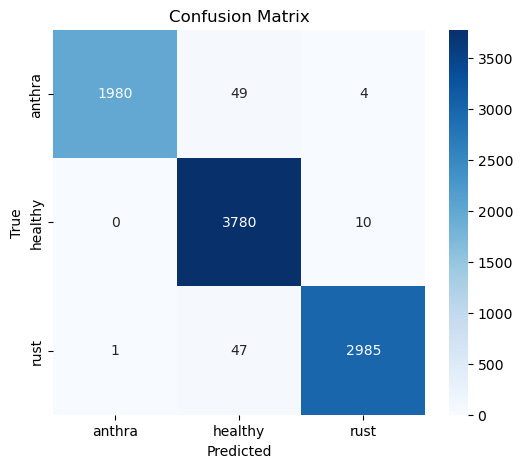

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## ROC Curves

Plotting per-class ROC curves with AUC scores for the distilled student model on the Beans test set.

In [42]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=range(n_classes))

In [43]:
roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9911415055856696


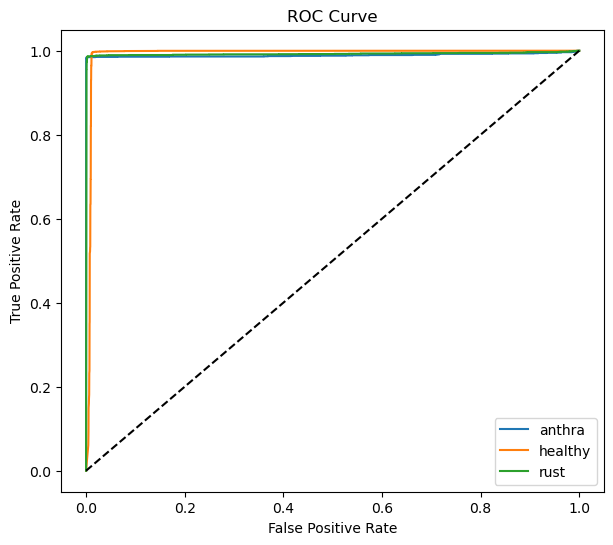

In [44]:
plt.figure(figsize=(7,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{class_names[i]}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()